# Multi-objective Assumption Robustness Test



**Feasible region:** rectangle $[x_{1,\text{lo}}, x_{1,\text{hi}}] \times [x_{2,\text{lo}}, x_{2,\text{hi}}]$ controlled by four parameters in Section 1. Default = $[0, P]^2$ with $P = F_\Gamma^{-1}(0.995)$ for $\Gamma(\text{shape}=2, \text{scale}=2)$.

**True objectives:** two convex quadratics $f_1, f_2$ with **non-monotone 2D ECDF discontinuities** added in the output space. No closed-form efficient set exists; we use discretization.

**Functional properties (both objectives):** `directional_Lipschitz_continuity` only. Lipschitz constants are computed analytically from $\nabla f$ over the rectangle (extrema at the 4 corners).



## 1. Common setup

In [1]:
import sys
import os
import time
import numpy as np
import scipy
import scipy.stats
import pyomo.environ as pyo
from multiprocessing import Pool, cpu_count
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.plausible_inference.model_construction import (
    model_construction,
    screening_x0_transfer,
    output_pixelization_pixel_transfer,
    input_pixelization_pixel_transfer,
)
from src.plausible_inference.utils.solver_config import get_plausibility_solver

In [2]:
# ============================================================
# Feasible region: rectangle  [x1_lo, x1_hi] x [x2_lo, x2_hi]
# Four parameters control the rectangle; set them however you like.
# Default = [0, P] x [0, P] with P = gamma(2, scale=2) 99.5%-quantile.
# ============================================================
tail_quantile_demand = 0.995
shape_demand = 2.0
scale_demand = 2.0
P = scipy.stats.gamma.ppf(tail_quantile_demand, shape_demand, scale=scale_demand)

# x1_lo, x1_hi = 0.0, P
# x2_lo, x2_hi = 0.0, P
x1_lo, x1_hi = 0, 15
x2_lo, x2_hi = 0, 15
print(f"Feasible rectangle: x1 ∈ [{x1_lo:.4f}, {x1_hi:.4f}],  x2 ∈ [{x2_lo:.4f}, {x2_hi:.4f}]")

# ============================================================
# True objective functions: two convex quadratics.
# star1 / star2 are FIXED so the underlying functions stay the same
# whatever rectangle you choose above.  (If you shrink the rectangle
# so much that star1 or star2 falls outside, the analytical efficient
# segment may leave the feasible region — that's on you.)
# ============================================================
Q1 = np.array([[2.0, 0.4], [0.4, 1.5]])
Q2 = np.array([[1.2, -0.3], [-0.3, 2.0]])

star1 = np.array([10.0, 2.0])   # argmin f1 (FIXED)
star2 = np.array([2.0, 10.0])   # argmin f2 (FIXED)

c1 = -Q1 @ star1
c2 = -Q2 @ star2
b1 = 0.2
b2 = 0.5

def _quad_f1_smooth(z):
    z = np.asarray(z, dtype=float).reshape(2,)
    return 0.5 * z @ Q1 @ z + c1 @ z + b1

def _quad_f2_smooth(z):
    z = np.asarray(z, dtype=float).reshape(2,)
    return 0.5 * z @ Q2 @ z + c2 @ z + b2

inside_rect_1 = (x1_lo <= star1[0] <= x1_hi) and (x2_lo <= star1[1] <= x2_hi)
inside_rect_2 = (x1_lo <= star2[0] <= x1_hi) and (x2_lo <= star2[1] <= x2_hi)
print(f"argmin f1 (smooth) = {star1}  (inside rectangle: {inside_rect_1})")
print(f"argmin f2 (smooth) = {star2}  (inside rectangle: {inside_rect_2})")

# ============================================================
# Add discontinuities via non-monotone 2D ECDF in INPUT space.
# Each objective gets its OWN independent ECDF noise (different
# sample points → different jump patterns).
# The noise is added to the OUTPUT values of f1, f2.
# ============================================================
n_ecdf_samples = 30       # total ECDF samples per objective (half forward, half reversed)
ecdf_noise_scale = 0.3    # fraction of each objective's range to use as noise amplitude

# --- ECDF noise for objective 1 ---
ecdf_rng1 = np.random.default_rng(2024)
ecdf_samp_x1_obj1 = ecdf_rng1.uniform(x1_lo, x1_hi, size=n_ecdf_samples)
ecdf_samp_x2_obj1 = ecdf_rng1.uniform(x2_lo, x2_hi, size=n_ecdf_samples)
n_half_ecdf = n_ecdf_samples // 2
n_rev_ecdf = n_ecdf_samples - n_half_ecdf
s_x1_fwd_1, s_x2_fwd_1 = ecdf_samp_x1_obj1[:n_half_ecdf], ecdf_samp_x2_obj1[:n_half_ecdf]
s_x1_rev_1, s_x2_rev_1 = ecdf_samp_x1_obj1[n_half_ecdf:], ecdf_samp_x2_obj1[n_half_ecdf:]

# --- ECDF noise for objective 2 (different seed → different pattern) ---
ecdf_rng2 = np.random.default_rng(7777)
ecdf_samp_x1_obj2 = ecdf_rng2.uniform(x1_lo, x1_hi, size=n_ecdf_samples)
ecdf_samp_x2_obj2 = ecdf_rng2.uniform(x2_lo, x2_hi, size=n_ecdf_samples)
s_x1_fwd_2, s_x2_fwd_2 = ecdf_samp_x1_obj2[:n_half_ecdf], ecdf_samp_x2_obj2[:n_half_ecdf]
s_x1_rev_2, s_x2_rev_2 = ecdf_samp_x1_obj2[n_half_ecdf:], ecdf_samp_x2_obj2[n_half_ecdf:]

def _ecdf_noise_obj1(x1_val, x2_val):
    """Non-monotone 2D ECDF noise for objective 1."""
    count_fwd = sum(1 for k in range(n_half_ecdf) if s_x1_fwd_1[k] <= x1_val and s_x2_fwd_1[k] <= x2_val)
    count_rev = sum(1 for k in range(n_rev_ecdf) if s_x1_rev_1[k] >= x1_val and s_x2_rev_1[k] >= x2_val)
    return count_fwd / n_half_ecdf - count_rev / n_rev_ecdf

def _ecdf_noise_obj2(x1_val, x2_val):
    """Non-monotone 2D ECDF noise for objective 2."""
    count_fwd = sum(1 for k in range(n_half_ecdf) if s_x1_fwd_2[k] <= x1_val and s_x2_fwd_2[k] <= x2_val)
    count_rev = sum(1 for k in range(n_rev_ecdf) if s_x1_rev_2[k] >= x1_val and s_x2_rev_2[k] >= x2_val)
    return count_fwd / n_half_ecdf - count_rev / n_rev_ecdf

# Determine output ranges to set noise amplitudes
_tmp_x1 = np.linspace(x1_lo, x1_hi, 100)
_tmp_x2 = np.linspace(x2_lo, x2_hi, 100)
_TMP_X1, _TMP_X2 = np.meshgrid(_tmp_x1, _tmp_x2)
_F1_tmp = 0.5 * (Q1[0,0]*_TMP_X1**2 + 2*Q1[0,1]*_TMP_X1*_TMP_X2 + Q1[1,1]*_TMP_X2**2) + c1[0]*_TMP_X1 + c1[1]*_TMP_X2 + b1
_F2_tmp = 0.5 * (Q2[0,0]*_TMP_X1**2 + 2*Q2[0,1]*_TMP_X1*_TMP_X2 + Q2[1,1]*_TMP_X2**2) + c2[0]*_TMP_X1 + c2[1]*_TMP_X2 + b2
f1_lo, f1_hi = float(_F1_tmp.min()), float(_F1_tmp.max())
f2_lo, f2_hi = float(_F2_tmp.min()), float(_F2_tmp.max())

# Noise amplitudes
noise_amp1 = ecdf_noise_scale * (f1_hi - f1_lo)
noise_amp2 = ecdf_noise_scale * (f2_hi - f2_lo)

def quad_f1(z):
    """Discontinuous objective 1: smooth quadratic + its own ECDF noise."""
    z = np.asarray(z, dtype=float).reshape(2,)
    val_smooth = 0.5 * z @ Q1 @ z + c1 @ z + b1
    return val_smooth + noise_amp1 * _ecdf_noise_obj1(z[0], z[1])

def quad_f2(z):
    """Discontinuous objective 2: smooth quadratic + its own ECDF noise."""
    z = np.asarray(z, dtype=float).reshape(2,)
    val_smooth = 0.5 * z @ Q2 @ z + c2 @ z + b2
    return val_smooth + noise_amp2 * _ecdf_noise_obj2(z[0], z[1])

print(f"Input-space ECDF noise: n_samples={n_ecdf_samples} per objective, scale={ecdf_noise_scale}")
print(f"  Obj1: seed=2024, f1 range=[{f1_lo:.2f}, {f1_hi:.2f}], noise_amp1={noise_amp1:.2f}")
print(f"  Obj2: seed=7777, f2 range=[{f2_lo:.2f}, {f2_hi:.2f}], noise_amp2={noise_amp2:.2f}")

# x0 feasibility (for input/output pixelization): A_ineq @ x0 <= b_ineq
# Rectangle:  x1 >= x1_lo,  x1 <= x1_hi,  x2 >= x2_lo,  x2 <= x2_hi
x0_feasible_region_A_ineq = np.array([
    [-1.0, 0.0],
    [1.0, 0.0],
    [0.0, -1.0],
    [0.0, 1.0],
])
x0_feasible_region_b_ineq = np.array([-x1_lo, x1_hi, -x2_lo, x2_hi])

Feasible rectangle: x1 ∈ [0.0000, 15.0000],  x2 ∈ [0.0000, 15.0000]
argmin f1 (smooth) = [10.  2.]  (inside rectangle: True)
argmin f2 (smooth) = [ 2. 10.]  (inside rectangle: True)
Input-space ECDF noise: n_samples=30 per objective, scale=0.3
  Obj1: seed=2024, f1 range=[-110.80, 66.95], noise_amp1=53.32
  Obj2: seed=7777, f2 range=[-95.90, 144.50], noise_amp2=72.12


In [3]:
# ============================================================
# Directional Lipschitz constants: analytical bounds on |∂f/∂x_d|
# over the rectangle. The gradient ∇f = Q x + c is linear, so its
# extrema are attained at the 4 corners of the rectangle.
# ============================================================
vertices = np.array([
    [x1_lo, x2_lo],
    [x1_hi, x2_lo],
    [x1_lo, x2_hi],
    [x1_hi, x2_hi],
])

def lip_vector(Q, c, vertices):
    grads = vertices @ Q.T + c
    return np.max(np.abs(grads), axis=0)

lip_CST_vector1 = lip_vector(Q1, c1, vertices).tolist()
lip_CST_vector2 = lip_vector(Q2, c2, vertices).tolist()
print("lip_CST_vector1 (obj1):", lip_CST_vector1)
print("lip_CST_vector2 (obj2):", lip_CST_vector2)

functional_properties_obj = {'directional_Lipschitz_continuity'}
functional_properties_list = [functional_properties_obj, functional_properties_obj]
functional_properties_parameters = [
    {'lip_CST_vector': lip_CST_vector1},
    {'lip_CST_vector': lip_CST_vector2},
]

num_of_objectives = 2
acceptability = 'Pareto-optimality'
discrepancy_type = 'confidence_region'

lip_CST_vector1 (obj1): [20.8, 21.5]
lip_CST_vector2 (obj2): [18.6, 23.9]


In [4]:
# ============================================================
# Grid / pixel layouts: all resolutions and ranges up top.
# ============================================================
#
#   --- KNOBS (edit here) ---------------------------------------------------
#   contour grid          (cosmetic, for f1/f2 surface plots)
n_contour            = 500

#   screening grid        (number of x0 points tested individually)
n_screen             = 60         # -> n_screen^2 = 10201 points

#   INPUT  pixel grid  (x0-space).  4 numbers fix the bbox directly.
n_grid_input         = 60          # resolution per axis  -> n^2 pixels
x0_d1_lo, x0_d1_hi   = x1_lo, x1_hi  # x1 range of the input pixel grid
x0_d2_lo, x0_d2_hi   = x2_lo, x2_hi  # x2 range of the input pixel grid

#   OUTPUT pixel grid  (m0-space).  4 numbers fix the bbox directly.
n_grid_obj1          = 24          # resolution along f1 axis
n_grid_obj2          = 45          # resolution along f2 axis  -> obj1*obj2 pixels
m0_d1_lo, m0_d1_hi   = -220.0, 0    # f1 range of the output pixel grid
m0_d2_lo, m0_d2_hi   = -220.0, 0    # f2 range of the output pixel grid
#   ------------------------------------------------------------------------


# --- Discretized Pareto front (replaces analytical solution) ---
# Evaluate the DISCONTINUOUS objectives on a dense grid; compute non-dominated set.
n_pareto_grid = 200
xs_pf = np.linspace(x1_lo, x1_hi, n_pareto_grid)
ys_pf = np.linspace(x2_lo, x2_hi, n_pareto_grid)
XX_pf, YY_pf = np.meshgrid(xs_pf, ys_pf)
pts_pareto_grid = np.column_stack([XX_pf.ravel(), YY_pf.ravel()])

f1_vals_pf = np.array([quad_f1(z) for z in pts_pareto_grid])
f2_vals_pf = np.array([quad_f2(z) for z in pts_pareto_grid])
obj_vals_pf = np.column_stack([f1_vals_pf, f2_vals_pf])

def pareto_mask(obj):
    """Boolean mask of non-dominated rows (minimisation)."""
    n = len(obj)
    order = np.argsort(obj[:, 0])
    obj_sorted = obj[order]
    keep_sorted = np.zeros(n, dtype=bool)
    min_f2 = np.inf
    for i in range(n):
        if obj_sorted[i, 1] < min_f2:
            keep_sorted[i] = True
            min_f2 = obj_sorted[i, 1]
    keep = np.zeros(n, dtype=bool)
    keep[order] = keep_sorted
    return keep

mask_pf = pareto_mask(obj_vals_pf)
pareto_x = pts_pareto_grid[mask_pf]
pareto_f = obj_vals_pf[mask_pf]
order_pf = np.argsort(pareto_f[:, 0])
pareto_x = pareto_x[order_pf]
pareto_f = pareto_f[order_pf]

# --- Contour grid over the rectangle (discontinuous objectives) ---
xs_c = np.linspace(x1_lo, x1_hi, n_contour)
ys_c = np.linspace(x2_lo, x2_hi, n_contour)
XX_c, YY_c = np.meshgrid(xs_c, ys_c)

_pts_c = np.column_stack([XX_c.ravel(), YY_c.ravel()])
F1_plot = np.array([quad_f1(z) for z in _pts_c]).reshape(XX_c.shape)
F2_plot = np.array([quad_f2(z) for z in _pts_c]).reshape(XX_c.shape)

# --- Screening grid over the rectangle ---
w1_values = np.linspace(x1_lo, x1_hi, n_screen)
w2_values = np.linspace(x2_lo, x2_hi, n_screen)
W1, W2 = np.meshgrid(w1_values, w2_values)
feas_region = np.vstack([W1.ravel(), W2.ravel()]).T

# --- Output (m0) pixel grid ---
d1_edges = np.linspace(m0_d1_lo, m0_d1_hi, n_grid_obj1 + 1)
d2_edges = np.linspace(m0_d2_lo, m0_d2_hi, n_grid_obj2 + 1)
output_pixels = [
    (np.array([d1_edges[i], d2_edges[j]]), np.array([d1_edges[i + 1], d2_edges[j + 1]]))
    for i in range(n_grid_obj1) for j in range(n_grid_obj2)
]

# --- Input (x0) pixel grid ---
w1_edges = np.linspace(x0_d1_lo, x0_d1_hi, n_grid_input + 1)
w2_edges = np.linspace(x0_d2_lo, x0_d2_hi, n_grid_input + 1)
input_pixels = [
    (np.array([w1_edges[i], w2_edges[j]]), np.array([w1_edges[i + 1], w2_edges[j + 1]]))
    for i in range(n_grid_input) for j in range(n_grid_input)
]

print(f"contour grid    : {n_contour} x {n_contour}")
print(f"screening grid  : {len(feas_region)} points  ({n_screen} x {n_screen})")
print(f"output pixels   : {len(output_pixels)}  ({n_grid_obj1} x {n_grid_obj2}, m0 bbox = [{m0_d1_lo:.2f}, {m0_d1_hi:.2f}] x [{m0_d2_lo:.2f}, {m0_d2_hi:.2f}])")
print(f"input  pixels   : {len(input_pixels)}  ({n_grid_input} x {n_grid_input}, x0 bbox = [{x0_d1_lo:.3f}, {x0_d1_hi:.3f}] x [{x0_d2_lo:.3f}, {x0_d2_hi:.3f}])")
print(f"Pareto-optimal points (discretization): {mask_pf.sum()} / {len(pts_pareto_grid)}")
print(f"Pareto front range: f1 in [{pareto_f[:,0].min():.3f}, {pareto_f[:,0].max():.3f}], f2 in [{pareto_f[:,1].min():.3f}, {pareto_f[:,1].max():.3f}]")

contour grid    : 500 x 500
screening grid  : 3600 points  (60 x 60)
output pixels   : 1080  (24 x 45, m0 bbox = [-220.00, 0.00] x [-220.00, 0.00])
input  pixels   : 3600  (60 x 60, x0 bbox = [0.000, 15.000] x [0.000, 15.000])
Pareto-optimal points (discretization): 140 / 40000
Pareto front range: f1 in [-126.401, -33.387], f2 in [-120.288, -4.026]


## 2. Contour plot of true objectives

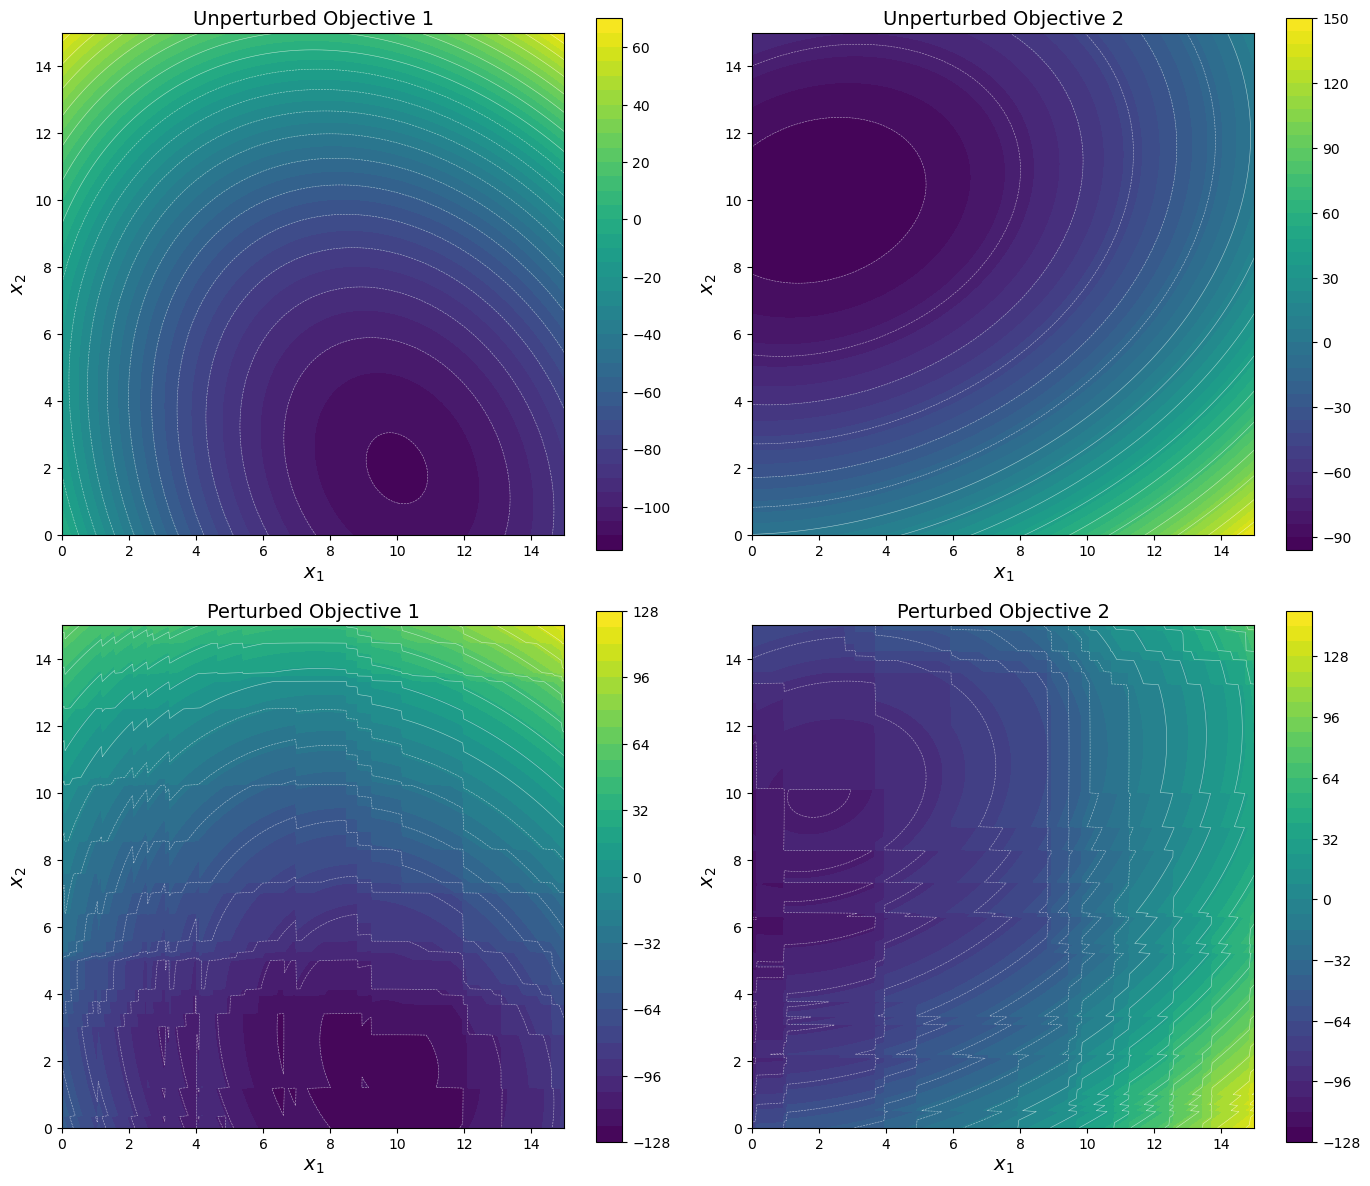

In [43]:
F1_smooth_plot = 0.5 * (Q1[0,0]*XX_c**2 + 2*Q1[0,1]*XX_c*YY_c + Q1[1,1]*YY_c**2) + c1[0]*XX_c + c1[1]*YY_c + b1
F2_smooth_plot = 0.5 * (Q2[0,0]*XX_c**2 + 2*Q2[0,1]*XX_c*YY_c + Q2[1,1]*YY_c**2) + c2[0]*XX_c + c2[1]*YY_c + b2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plots = [
    (axes[0, 0], F1_smooth_plot, "Unperturbed Objective 1"),
    (axes[0, 1], F2_smooth_plot, "Unperturbed Objective 2"),
    (axes[1, 0], F1_plot, "Perturbed Objective 1"),
    (axes[1, 1], F2_plot, "Perturbed Objective 2"),
]
for ax, F_plot, title in plots:
    cf = ax.contourf(XX_c, YY_c, F_plot, levels=40, cmap="viridis")
    ax.contour(XX_c, YY_c, F_plot, levels=20, colors="white", linewidths=0.4, alpha=0.6)
    fig.colorbar(cf, ax=ax)
    ax.set_xlabel(r"$x_1$", fontsize=14)
    ax.set_ylabel(r"$x_2$", fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()



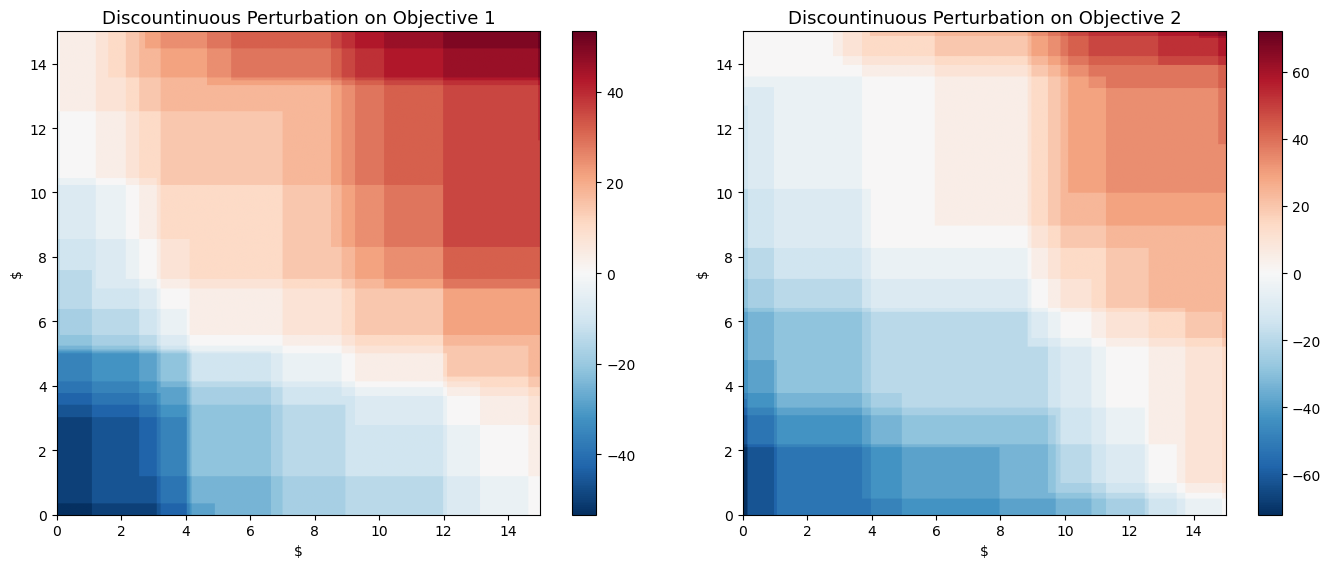

Noise 1 range: [-53.3, 53.3]
Noise 2 range: [-72.1, 72.1]


In [45]:
# Visualize the two independent ECDF noise patterns.

# Noise for objective 1
_noise_fwd_1 = np.zeros(XX_c.shape)
for k in range(n_half_ecdf):
    _noise_fwd_1 += (s_x1_fwd_1[k] <= XX_c) & (s_x2_fwd_1[k] <= YY_c)
_noise_fwd_1 /= n_half_ecdf
_noise_rev_1 = np.zeros(XX_c.shape)
for k in range(n_rev_ecdf):
    _noise_rev_1 += (s_x1_rev_1[k] >= XX_c) & (s_x2_rev_1[k] >= YY_c)
_noise_rev_1 /= n_rev_ecdf
_ecdf_surface_1 = _noise_fwd_1 - _noise_rev_1

# Noise for objective 2
_noise_fwd_2 = np.zeros(XX_c.shape)
for k in range(n_half_ecdf):
    _noise_fwd_2 += (s_x1_fwd_2[k] <= XX_c) & (s_x2_fwd_2[k] <= YY_c)
_noise_fwd_2 /= n_half_ecdf
_noise_rev_2 = np.zeros(XX_c.shape)
for k in range(n_rev_ecdf):
    _noise_rev_2 += (s_x1_rev_2[k] >= XX_c) & (s_x2_rev_2[k] >= YY_c)
_noise_rev_2 /= n_rev_ecdf
_ecdf_surface_2 = _noise_fwd_2 - _noise_rev_2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Noise for f1
ax = axes[0]
cf = ax.imshow(noise_amp1 * _ecdf_surface_1, origin="lower",
              extent=[x1_lo, x1_hi, x2_lo, x2_hi], aspect="equal", cmap="RdBu_r")
# ax.scatter(s_x1_fwd_1, s_x2_fwd_1, c="blue", s=25, marker="^", zorder=5, label=r"Decrease Jump")
# ax.scatter(s_x1_rev_1, s_x2_rev_1, c="red", s=25, marker="v", zorder=5, label=r"Increase Jump")
ax.set_title(r"Discountinuous Perturbation on Objective 1", fontsize=13)
ax.set_xlabel(r"$"); ax.set_ylabel(r"$")
# ax.legend(loc="lower right", fontsize=9)
fig.colorbar(cf, ax=ax)

# Noise for f2
ax = axes[1]
cf = ax.imshow(noise_amp2 * _ecdf_surface_2, origin="lower",
              extent=[x1_lo, x1_hi, x2_lo, x2_hi], aspect="equal", cmap="RdBu_r")
# ax.scatter(s_x1_fwd_2, s_x2_fwd_2, c="blue", s=25, marker="^", zorder=5, label=r"Decrease Jump")
# ax.scatter(s_x1_rev_2, s_x2_rev_2, c="red", s=25, marker="v", zorder=5, label=r"Increase Jump")
ax.set_title(r"Discountinuous Perturbation on Objective 2", fontsize=13)
ax.set_xlabel(r"$"); ax.set_ylabel(r"$")
# ax.legend(loc="lower right", fontsize=9)
fig.colorbar(cf, ax=ax)

#plt.suptitle("Independent ECDF noise patterns for each objective", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Noise 1 range: [{(noise_amp1*_ecdf_surface_1).min():.1f}, {(noise_amp1*_ecdf_surface_1).max():.1f}]")
print(f"Noise 2 range: [{(noise_amp2*_ecdf_surface_2).min():.1f}, {(noise_amp2*_ecdf_surface_2).max():.1f}]")

## 3. Discretized efficient set & Pareto front

With discontinuous objectives, no closed-form efficient set exists. We compute the Pareto front
by evaluating both objectives on a dense grid and extracting the non-dominated set.


In [7]:
# Pareto front already computed in the grids cell (pareto_x, pareto_f).
print(f"Discretization points: {len(pts_pareto_grid)}")
print(f"Pareto-optimal points: {len(pareto_x)}")
print(f"Pareto front f1 range: [{pareto_f[:, 0].min():.3f}, {pareto_f[:, 0].max():.3f}]")
print(f"Pareto front f2 range: [{pareto_f[:, 1].min():.3f}, {pareto_f[:, 1].max():.3f}]")

Discretization points: 40000
Pareto-optimal points: 140
Pareto front f1 range: [-126.401, -33.387]
Pareto front f2 range: [-120.288, -4.026]


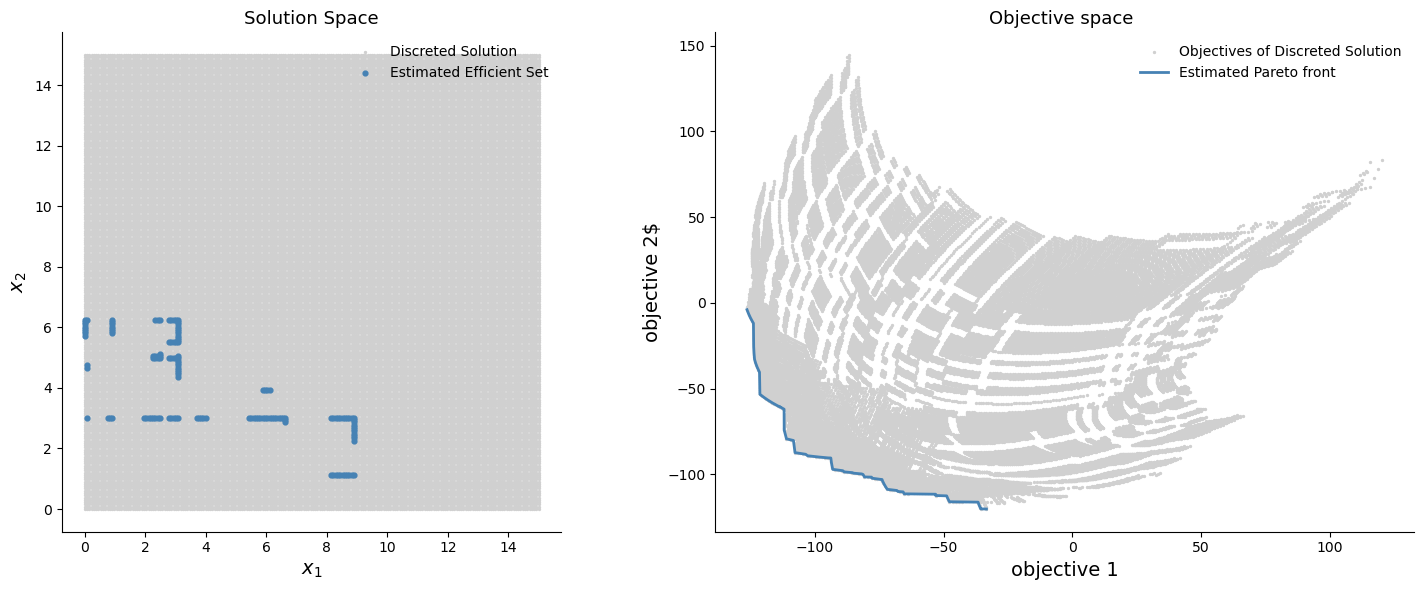

In [32]:
rect_x = [x1_lo, x1_hi, x1_hi, x1_lo, x1_lo]
rect_y = [x2_lo, x2_lo, x2_hi, x2_hi, x2_lo]

fig, (ax_x, ax_f) = plt.subplots(1, 2, figsize=(15, 6))

# decision space
ax_x.scatter(pts_pareto_grid[:, 0], pts_pareto_grid[:, 1], s=2, c="#d0d0d0", label="Discreted Solution")
ax_x.scatter(pareto_x[:, 0], pareto_x[:, 1], s=12, c="steelblue", zorder=3, label="Estimated Efficient Set")
# ax_x.plot(rect_x, rect_y, "k-", linewidth=1.0)
ax_x.set_xlabel(r"$x_1$", fontsize=14); ax_x.set_ylabel(r"$x_2$", fontsize=14)
ax_x.set_title("Solution Space", fontsize=13); ax_x.set_aspect("equal")
ax_x.legend(fontsize=10, frameon=False)

# objective space
ax_f.scatter(obj_vals_pf[:, 0], obj_vals_pf[:, 1], s=2, c="#d0d0d0", label="Objectives of Discreted Solution")
ax_f.plot(pareto_f[:, 0], pareto_f[:, 1], "-", c="steelblue", linewidth=2, label="Estimated Pareto front")
ax_f.set_xlabel(r"objective 1", fontsize=14); ax_f.set_ylabel(r"objective 2$", fontsize=14)
ax_f.set_title("Objective space ", fontsize=13)
ax_f.legend(fontsize=10, frameon=False)

for sp in ["top", "right"]:
    ax_x.spines[sp].set_visible(False)
    ax_f.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Synthetic experimental data

`exp_set` is a regular **grid** of `num_exp_d1 × num_exp_d2` points over the rectangle (endpoints included). At each design point draw `n_rep` noisy observations of both objectives; build pointwise 95% confidence intervals.

In [9]:
rng = np.random.default_rng(42)

#   --- exp_set is a regular grid over the rectangle (edit these) ---
num_exp_d1 = 10       # number of design points along x1
num_exp_d2 = 10       # number of design points along x2
#   ----------------------------------------------------------------

n_rep = 1000           # replications per design point
noise_std1 = 0.3      # noise σ for objective 1
noise_std2 = 0.4      # noise σ for objective 2
confidence_level = 0.95

# Regular grid over [x1_lo, x1_hi] x [x2_lo, x2_hi]
x1_grid = np.linspace(x1_lo, x1_hi, num_exp_d1)
x2_grid = np.linspace(x2_lo, x2_hi, num_exp_d2)
XE, YE = np.meshgrid(x1_grid, x2_grid)
exp_set = np.column_stack([XE.ravel(), YE.ravel()])
num_exp = exp_set.shape[0]

sample_mean = np.zeros((num_exp, 2))
sample_var = np.zeros((num_exp, 2))
for i, z in enumerate(exp_set):
    y1 = quad_f1(z) + rng.normal(0, noise_std1, n_rep)
    y2 = quad_f2(z) + rng.normal(0, noise_std2, n_rep)
    sample_mean[i, 0] = y1.mean(); sample_mean[i, 1] = y2.mean()
    sample_var[i, 0] = y1.var(ddof=1); sample_var[i, 1] = y2.var(ddof=1)

t_crit = scipy.stats.t.ppf(0.5 + confidence_level / 2, df=n_rep - 1)
half_width = t_crit * np.sqrt(sample_var / n_rep)
lower_confidence_bounds = sample_mean - half_width
upper_confidence_bounds = sample_mean + half_width

k_val = exp_set.shape[0]
s_val = exp_set.shape[1]
print(f"exp_set: {num_exp_d1} x {num_exp_d2} = {k_val} grid points, dimension {s_val}")
print(f"LB obj1 range: [{lower_confidence_bounds[:, 0].min():.3f}, {lower_confidence_bounds[:, 0].max():.3f}]")
print(f"UB obj1 range: [{upper_confidence_bounds[:, 0].min():.3f}, {upper_confidence_bounds[:, 0].max():.3f}]")
print(f"LB obj2 range: [{lower_confidence_bounds[:, 1].min():.3f}, {lower_confidence_bounds[:, 1].max():.3f}]")
print(f"UB obj2 range: [{upper_confidence_bounds[:, 1].min():.3f}, {upper_confidence_bounds[:, 1].max():.3f}]")

exp_set: 10 x 10 = 100 grid points, dimension 2
LB obj1 range: [-122.051, 120.251]
UB obj1 range: [-122.015, 120.288]
LB obj2 range: [-113.261, 144.516]
UB obj2 range: [-113.211, 144.569]


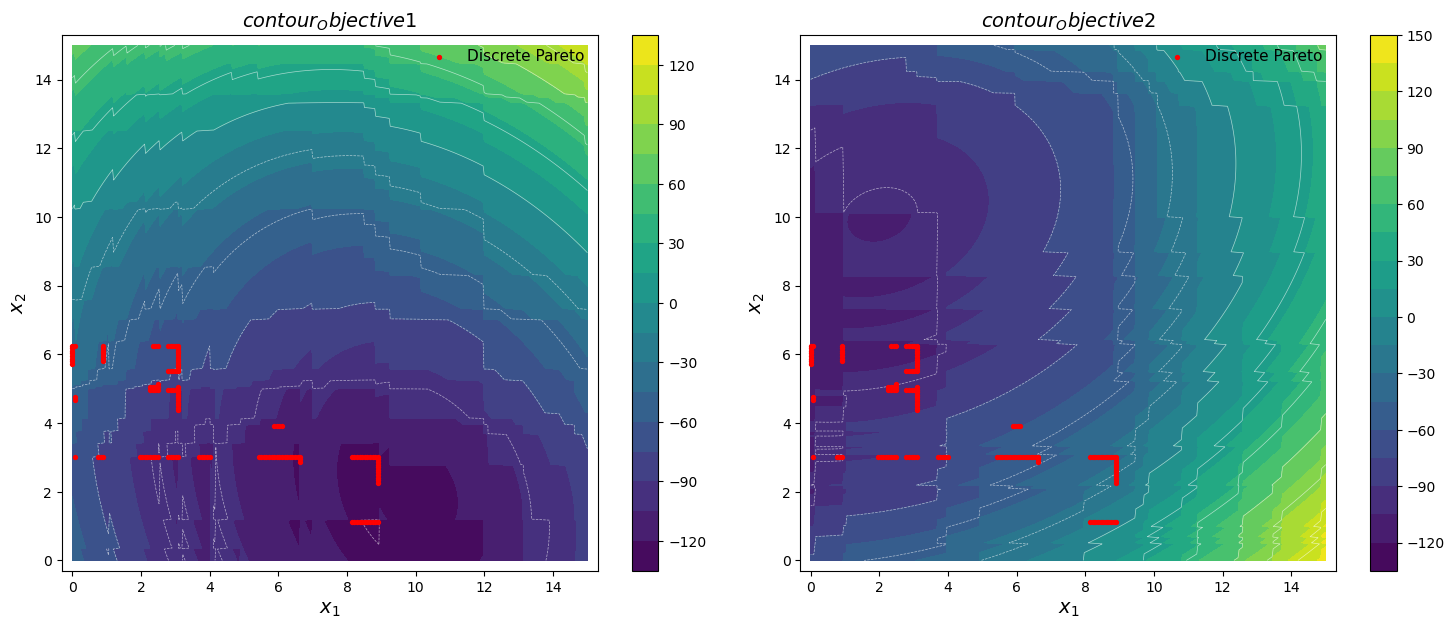

In [28]:
rect_x = [x1_lo, x1_hi, x1_hi, x1_lo, x1_lo]
rect_y = [x2_lo, x2_lo, x2_hi, x2_hi, x2_lo]
pad_dx = 0.02 * (x1_hi - x1_lo)
pad_dy = 0.02 * (x2_hi - x2_lo)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, F_plot, title in zip(axes, [F1_plot, F2_plot], [r'$contour_Objective 1$', r'$contour_Objective 2$']):
    cf = ax.contourf(XX_c, YY_c, F_plot, levels=20, cmap='viridis')
    ax.contour(XX_c, YY_c, F_plot, levels=10, colors='white', linewidths=0.5, alpha=0.6)
    ax.scatter(pareto_x[:, 0], pareto_x[:, 1], s=8, c='red', zorder=4, label='Discrete Pareto')
    # ax.scatter(exp_set[:, 0], exp_set[:, 1], s=60, marker='D', facecolors='none', edgecolors='white',
    #            linewidths=2, label='Design points')
    # ax.plot(rect_x, rect_y, 'k-', linewidth=1.5)
    plt.colorbar(cf, ax=ax)
    ax.set_xlabel(r'$x_1$', fontsize=14); ax.set_ylabel(r'$x_2$', fontsize=14)
    ax.set_title(title, fontsize=14); ax.set_aspect('equal')
    ax.set_xlim(x1_lo - pad_dx, x1_hi + pad_dx); ax.set_ylim(x2_lo - pad_dy, x2_hi + pad_dy)
    ax.legend(fontsize=11, frameon=False, loc='upper right')
plt.tight_layout(); plt.show()

## 4b. Estimate directional Lipschitz constants from data



In [11]:
def estimate_lipschitz_one_direction(exp_set, lb_obj, ub_obj, s_to_minimize, solver):
    """
    Solve the LP:
        variables   :  m_i  ∈ [lb_obj[i], ub_obj[i]] for i=1..k
                       L_s  ≥ 0  for s=1..S
        constraints :  m_i - m_j  ≤  Σ_s L_s * |x_{i,s} - x_{j,s}|   ∀ i ≠ j
        objective   :  minimize  L_{s_to_minimize}

    Returns the optimal value of L_{s_to_minimize} (and the optimal m_i is
    chosen anywhere in its CI that makes the constraints tight enough).
    s_to_minimize is 0-indexed (0 = first direction, 1 = second direction).
    """
    k, S = exp_set.shape
    model = pyo.ConcreteModel()
    model.K_set = pyo.Set(initialize=range(k))
    model.S_set = pyo.Set(initialize=range(S))

    def m_bounds(model, i):
        return (float(lb_obj[i]), float(ub_obj[i]))
    model.m = pyo.Var(model.K_set, domain=pyo.Reals, bounds=m_bounds)
    model.L = pyo.Var(model.S_set, domain=pyo.NonNegativeReals)

    def dir_lip_rule(model, i, j):
        if i == j:
            return pyo.Constraint.Skip
        return model.m[i] - model.m[j] <= sum(
            abs(exp_set[i, s] - exp_set[j, s]) * model.L[s] for s in model.S_set
        )
    model.dir_lip_con = pyo.Constraint(model.K_set, model.K_set, rule=dir_lip_rule)

    model.OBJ = pyo.Objective(expr=model.L[s_to_minimize], sense=pyo.minimize)
    solver.solve(model, tee=False)
    return float(pyo.value(model.L[s_to_minimize]))


solver_est = get_plausibility_solver('gurobi')

# 4 LPs: 2 objectives x 2 directions
lip_CST_vector1_est = [
    estimate_lipschitz_one_direction(
        exp_set,
        lower_confidence_bounds[:, 0], upper_confidence_bounds[:, 0],
        s_to_minimize=s, solver=solver_est,
    )
    for s in range(s_val)
]
lip_CST_vector2_est = [
    estimate_lipschitz_one_direction(
        exp_set,
        lower_confidence_bounds[:, 1], upper_confidence_bounds[:, 1],
        s_to_minimize=s, solver=solver_est,
    )
    for s in range(s_val)
]

# Keep the true (corner-of-rectangle) values around just for the printout
lip_CST_vector1_true = list(lip_CST_vector1)
lip_CST_vector2_true = list(lip_CST_vector2)

print("Directional Lipschitz constants — true vs. estimated:")
print(f"  obj1  true: [{lip_CST_vector1_true[0]:>10.4f}, {lip_CST_vector1_true[1]:>10.4f}]")
print(f"  obj1  est : [{lip_CST_vector1_est[0]:>10.4f}, {lip_CST_vector1_est[1]:>10.4f}]")
print(f"  obj2  true: [{lip_CST_vector2_true[0]:>10.4f}, {lip_CST_vector2_true[1]:>10.4f}]")
print(f"  obj2  est : [{lip_CST_vector2_est[0]:>10.4f}, {lip_CST_vector2_est[1]:>10.4f}]")

# Override the values used by the model in Sections 5/6/7.
lip_CST_vector1 = lip_CST_vector1_est
lip_CST_vector2 = lip_CST_vector2_est
functional_properties_parameters = [
    {'lip_CST_vector': lip_CST_vector1},
    {'lip_CST_vector': lip_CST_vector2},
]
print("\nfunctional_properties_parameters now use the ESTIMATED constants for all downstream inference.")

Directional Lipschitz constants — true vs. estimated:
  obj1  true: [   20.8000,    21.5000]
  obj1  est : [   16.9667,    28.7517]
  obj2  true: [   18.6000,    23.9000]
  obj2  est : [   26.2347,    21.7069]

functional_properties_parameters now use the ESTIMATED constants for all downstream inference.


## 5. Screening

Regular $101 \times 101$ grid over the rectangle; for each grid point, test whether it can be Pareto-optimal under the directional-Lipschitz assumption.

In [12]:
# feas_region is pre-computed in the grids cell.
inference_type_screening = 'screening'
print(f"Number of screening points: {len(feas_region)}")
print("Building screening model...")
model_start = time.time()
M_model_screening = model_construction(
    exp_set,
    num_of_objectives,
    inference_type_screening,
    functional_properties_list,
    acceptability=acceptability,
    discrepancy_type=discrepancy_type,
    upper_confidence_bounds=upper_confidence_bounds,
    lower_confidence_bounds=lower_confidence_bounds,
    functional_properties_parameters=functional_properties_parameters,
)
solver_screening = get_plausibility_solver('gurobi')
print(f"Screening model built in {time.time() - model_start:.4f} s")

Number of screening points: 3600
Building screening model...
Screening model built in 0.3011 s


In [13]:
tasks_screening = [
    (idx, feas_region[idx, :], M_model_screening, solver_screening)
    for idx in range(len(feas_region))
]
MAX_WORKERS = cpu_count()

print(f"Solving screening for {len(tasks_screening)} points with {MAX_WORKERS} workers...")
solve_start = time.time()
with Pool(processes=MAX_WORKERS) as pool:
    screening_results = pool.map(screening_x0_transfer, tasks_screening)
print(f"Screening done in {time.time() - solve_start:.2f} s")

n_feas = sum(1 for r in screening_results if r.get('feasible', False))
print(f"  Feasible:   {n_feas}")
print(f"  Infeasible: {len(screening_results) - n_feas}")

Solving screening for 3600 points with 16 workers...
Screening done in 36.62 s
  Feasible:   1665
  Infeasible: 1935


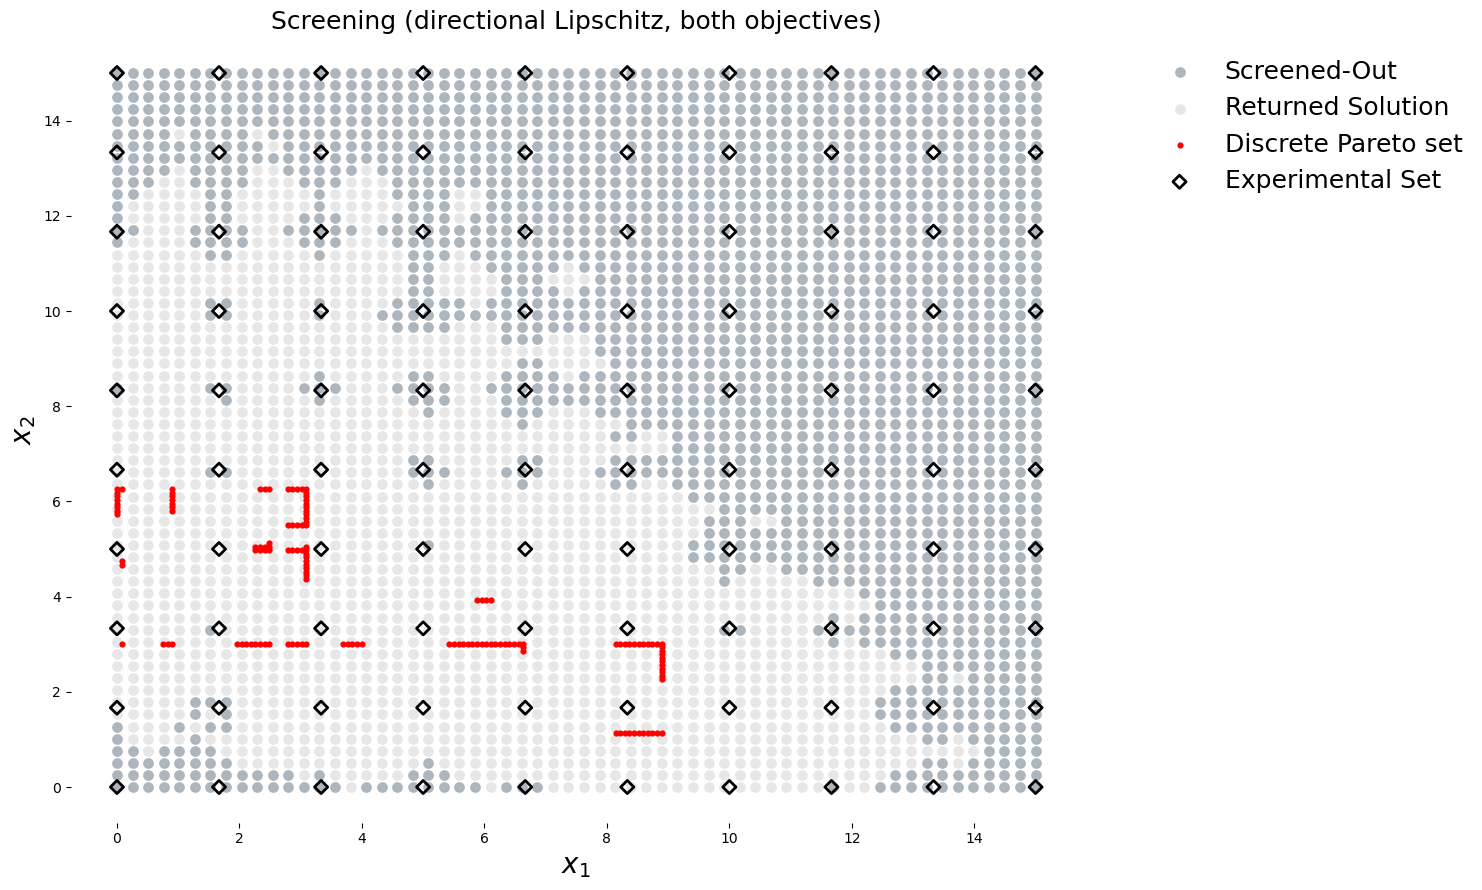

In [25]:
color_0 = '#e7e7e7'
color_1 = '#adb5bd'
color_2 = 'black'

feasibility_array = np.zeros(len(feas_region), dtype=int)
for result in screening_results:
    feasibility_array[result['idx']] = 1 if result.get('feasible', False) else 0

rect_x = [x1_lo, x1_hi, x1_hi, x1_lo, x1_lo]
rect_y = [x2_lo, x2_lo, x2_hi, x2_hi, x2_lo]

plt.figure(figsize=(15, 9))
scatter_size = 45
mask_infeasible = (feasibility_array == 0)
plt.scatter(feas_region[mask_infeasible, 0], feas_region[mask_infeasible, 1],
            c=color_1, s=scatter_size, label='Screened-Out')
mask_feasible = (feasibility_array == 1)
plt.scatter(feas_region[mask_feasible, 0], feas_region[mask_feasible, 1],
            c=color_0, s=scatter_size, label='Returned Solution')
plt.scatter(pareto_x[:, 0], pareto_x[:, 1], s=12, c='red',
         zorder=4, label='Discrete Pareto set')
plt.scatter(exp_set[:, 0], exp_set[:, 1], s=scatter_size, color='none',
            edgecolors=color_2, label='Experimental Set', linewidths=2, marker='D', zorder=5)
# plt.plot(rect_x, rect_y, 'k-', linewidth=1.0)

ax = plt.gca()
for sp in ['left', 'bottom']: ax.spines[sp].set_linewidth(0)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.xlabel(r'$x_1$', fontsize=20); plt.ylabel(r'$x_2$', fontsize=20)
# plt.tick_params(axis='both', which='major', labelsize=20)
plt.title('Screening (directional Lipschitz, both objectives)', fontsize=18)
plt.legend(fontsize=18, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 6. Output pixelization (output screening)

Pixelize the **output space** `m[0, :]`. `x0` is a decision variable; we constrain `m[0, d]` to lie in a small pixel `[m0_lb, m0_ub]` per objective. The grid range is set from the **analytical Pareto front** (line segment image) with a small padding.

In [15]:
inference_type_output = 'output_pixelization'

print("Building output_pixelization model...")
model_start = time.time()
solver_output = get_plausibility_solver('scip')
M_model_output = model_construction(
    exp_set,
    num_of_objectives,
    inference_type_output,
    functional_properties_list,
    acceptability=acceptability,
    discrepancy_type=discrepancy_type,
    upper_confidence_bounds=upper_confidence_bounds,
    lower_confidence_bounds=lower_confidence_bounds,
    functional_properties_parameters=functional_properties_parameters,
    feasibility_check_solver=None,
    x0_feasible_region_A_ineq=x0_feasible_region_A_ineq,
    x0_feasible_region_b_ineq=x0_feasible_region_b_ineq,
)
print(f"Output_pixelization model built in {time.time() - model_start:.4f} s")

Building output_pixelization model...
Output_pixelization model built in 0.1066 s


In [16]:
TIMEOUT_SEC_OUTPUT = 90
tasks_output = [
    (idx, output_pixels[idx][0], output_pixels[idx][1], M_model_output, solver_output, TIMEOUT_SEC_OUTPUT)
    for idx in range(len(output_pixels))
]

print(f"Solving {len(tasks_output)} output pixels with {MAX_WORKERS} workers (time_limit={TIMEOUT_SEC_OUTPUT}s/task)...")
solve_start = time.time()
output_results = []
with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(output_pixelization_pixel_transfer, t) for t in tasks_output]
    for future in futures:
        output_results.append(future.result())

n_timeout = sum(1 for r in output_results if r.get('timeout'))
n_feas = sum(1 for r in output_results if r.get('feasible', False))
print(f"Output_pixelization done in {time.time() - solve_start:.2f} s")
print(f"  Feasible:   {n_feas}")
print(f"  Infeasible: {len(output_results) - n_feas - n_timeout}")
print(f"  Timeout:    {n_timeout}")

Solving 1080 output pixels with 16 workers (time_limit=90s/task)...
Output_pixelization done in 691.00 s
  Feasible:   239
  Infeasible: 841
  Timeout:    0


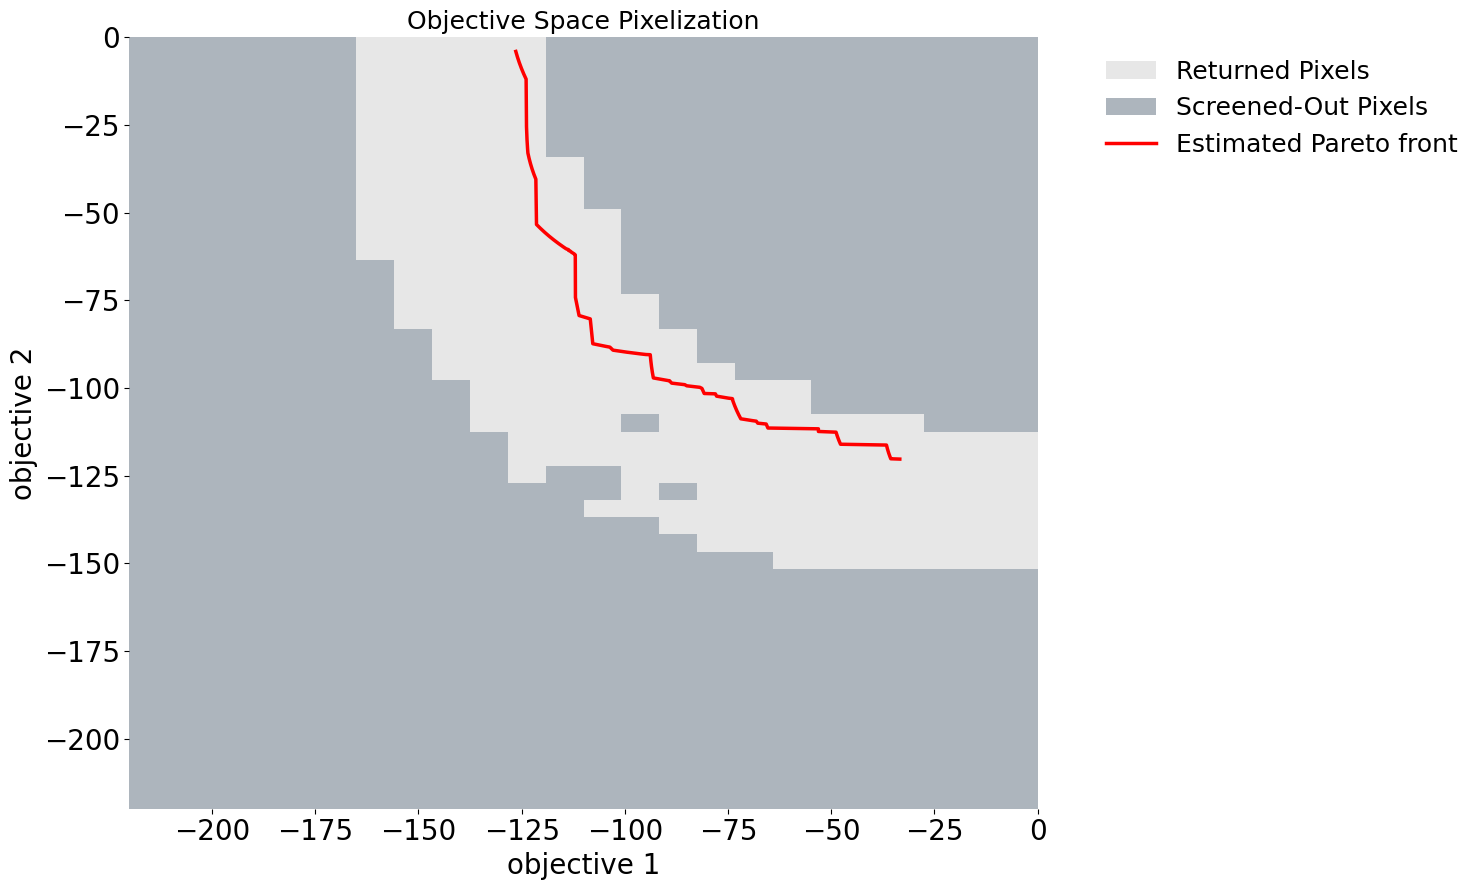

In [24]:
feasibility_by_idx_output = {
    r['idx']: (2 if r.get('timeout') else (1 if r.get('feasible', False) else 0))
    for r in output_results
}
feasibility_grid_output = np.array(
    [feasibility_by_idx_output.get(idx, 0) for idx in range(len(output_pixels))]
).reshape(n_grid_obj1, n_grid_obj2)

color_timeout = '#f59f00'
cmap_output = ListedColormap([color_1, color_0, color_timeout])

plt.figure(figsize=(15, 9))
plt.pcolormesh(d1_edges, d2_edges, feasibility_grid_output.T,
               shading='flat', cmap=cmap_output, vmin=0, vmax=2)
plt.plot(pareto_f[:, 0], pareto_f[:, 1], '-', c='red', linewidth=2.5,
         label='Discrete Pareto front')

ax = plt.gca()
for sp in ['left', 'bottom']: ax.spines[sp].set_linewidth(0)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.xlabel(r'objective 1', fontsize=20)
plt.ylabel(r'objective 2', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.title('Objective Space Pixelization', fontsize=18)
legend_handles_output = [
    Patch(facecolor=color_0, label='Returned Pixels'),
    Patch(facecolor=color_1, label='Screened-Out Pixels'),
    # Patch(facecolor=color_timeout, label='Timeout'),
    Line2D([0], [0], color='red', linewidth=2.5, label='Estimated Pareto front'),
]
ax.legend(handles=legend_handles_output, fontsize=18, frameon=False,
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 7. Input pixelization (input screening)

Pixelize the **input/solution space** `x0`. The grid is built over an axis-aligned bounding box around the **analytical efficient set** with padding (clipped to the rectangle): this concentrates pixels where the Pareto activity is, keeping the count tractable.

In [18]:
inference_type_input = 'input_pixelization'

print("Building input_pixelization model...")
model_start = time.time()
solver_input = get_plausibility_solver('scip')
M_model_input = model_construction(
    exp_set,
    num_of_objectives,
    inference_type_input,
    functional_properties_list,
    acceptability=acceptability,
    discrepancy_type=discrepancy_type,
    upper_confidence_bounds=upper_confidence_bounds,
    lower_confidence_bounds=lower_confidence_bounds,
    functional_properties_parameters=functional_properties_parameters,
    feasibility_check_solver=None,
    x0_feasible_region_A_ineq=x0_feasible_region_A_ineq,
    x0_feasible_region_b_ineq=x0_feasible_region_b_ineq,
)
print(f"Input_pixelization model built in {time.time() - model_start:.4f} s")

Building input_pixelization model...
Input_pixelization model built in 0.1224 s


In [19]:
tasks_input = [
    (idx, input_pixels[idx][0], input_pixels[idx][1], M_model_input, solver_input)
    for idx in range(len(input_pixels))
]

print(f"Solving {len(tasks_input)} input pixels with {MAX_WORKERS} workers...")
solve_start = time.time()
with Pool(processes=MAX_WORKERS) as pool:
    input_results = pool.map(input_pixelization_pixel_transfer, tasks_input)

n_feas = sum(1 for r in input_results if r.get('feasible', False))
print(f"Input_pixelization done in {time.time() - solve_start:.2f} s")
print(f"  Feasible:   {n_feas}")
print(f"  Infeasible: {len(input_results) - n_feas}")

Solving 3600 input pixels with 16 workers...
Input_pixelization done in 63.72 s
  Feasible:   1928
  Infeasible: 1672


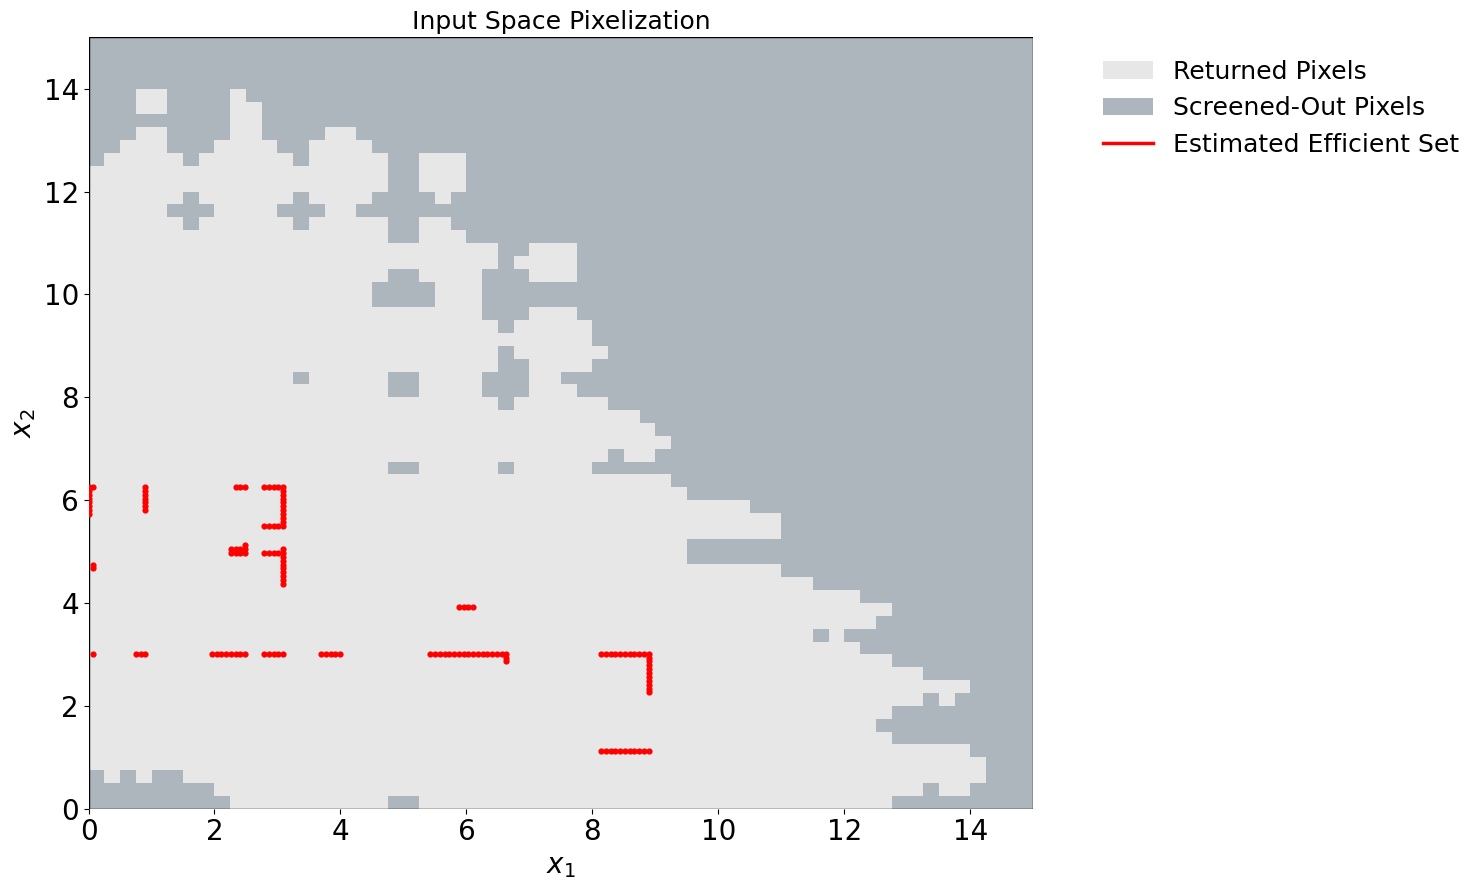

In [22]:
feasibility_by_idx_input = {r['idx']: (1 if r.get('feasible', False) else 0) for r in input_results}
feasibility_grid_input = np.array(
    [feasibility_by_idx_input.get(idx, 0) for idx in range(len(input_pixels))]
).reshape(n_grid_input, n_grid_input)

cmap_input = ListedColormap([color_1, color_0])

rect_x = [x1_lo, x1_hi, x1_hi, x1_lo, x1_lo]
rect_y = [x2_lo, x2_lo, x2_hi, x2_hi, x2_lo]

plt.figure(figsize=(15, 9))
plt.pcolormesh(w1_edges, w2_edges, feasibility_grid_input.T,
               shading='flat', cmap=cmap_input, vmin=0, vmax=1)
plt.scatter(pareto_x[:, 0], pareto_x[:, 1], s=12, c='red',
         zorder=4, label='Discrete Pareto set')
# plt.scatter(exp_set[:, 0], exp_set[:, 1], s=45, color='none',
#             edgecolors=color_2, label='Experimental Set', linewidths=2, marker='D', zorder=5)
plt.plot(rect_x, rect_y, 'k-', linewidth=1.0)

ax = plt.gca()
for sp in ['left', 'bottom']: ax.spines[sp].set_linewidth(0)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.xlabel(r'$x_1$', fontsize=20); plt.ylabel(r'$x_2$', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.title('Input Space Pixelization', fontsize=18)
legend_handles_input = [
    Patch(facecolor=color_0, label='Returned Pixels'),
    Patch(facecolor=color_1, label='Screened-Out Pixels'),
    Line2D([0], [0], color='red', linewidth=2.5, label='Estimated Efficient Set'),
    # Line2D([0], [0], marker='D', color='w', markerfacecolor='none', markeredgecolor=color_2,
    #        markeredgewidth=2, markersize=8, label='Experimental Set'),
]
ax.legend(handles=legend_handles_input, fontsize=18, frameon=False,
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()